# AI Resume Screener — Model Training
**Dataset:** Kaggle Resume Dataset | **Task:** Multi-class Resume Category Classification

### Pipeline Overview
1. Load & Explore Data
2. Text Preprocessing & Cleaning
3. EDA — Category Distribution
4. TF-IDF Vectorization
5. Train Multiple ML Models (Scikit-learn)
6. Deep Learning Model (Keras)
7. Model Evaluation & Comparison
8. Save Best Model

---
## Step 1 — Install & Import Libraries

In [20]:
# Install required packages (run once)
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud nltk

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\GAURAV\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\GAURAV\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\GAURAV\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


---
## Step 2 — Load Dataset

In [22]:
# Load the dataset
df = pd.read_csv('resume_data.csv')

print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Dataset Shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [23]:
# Basic info
print('=== Dataset Info ===')
print(f'Total Resumes  : {len(df)}')
print(f'Total Categories: {df["Category"].nunique()}')
print(f'Missing Values :')
print(df.isnull().sum())

# We only need Resume_str and Category
df = df[['Resume_str', 'Category']].copy()
df.rename(columns={'Resume_str': 'resume_text'}, inplace=True)
print('\nWorking columns:', df.columns.tolist())

=== Dataset Info ===
Total Resumes  : 2484
Total Categories: 24
Missing Values :
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Working columns: ['resume_text', 'Category']


---
## Step 3 — Exploratory Data Analysis (EDA)

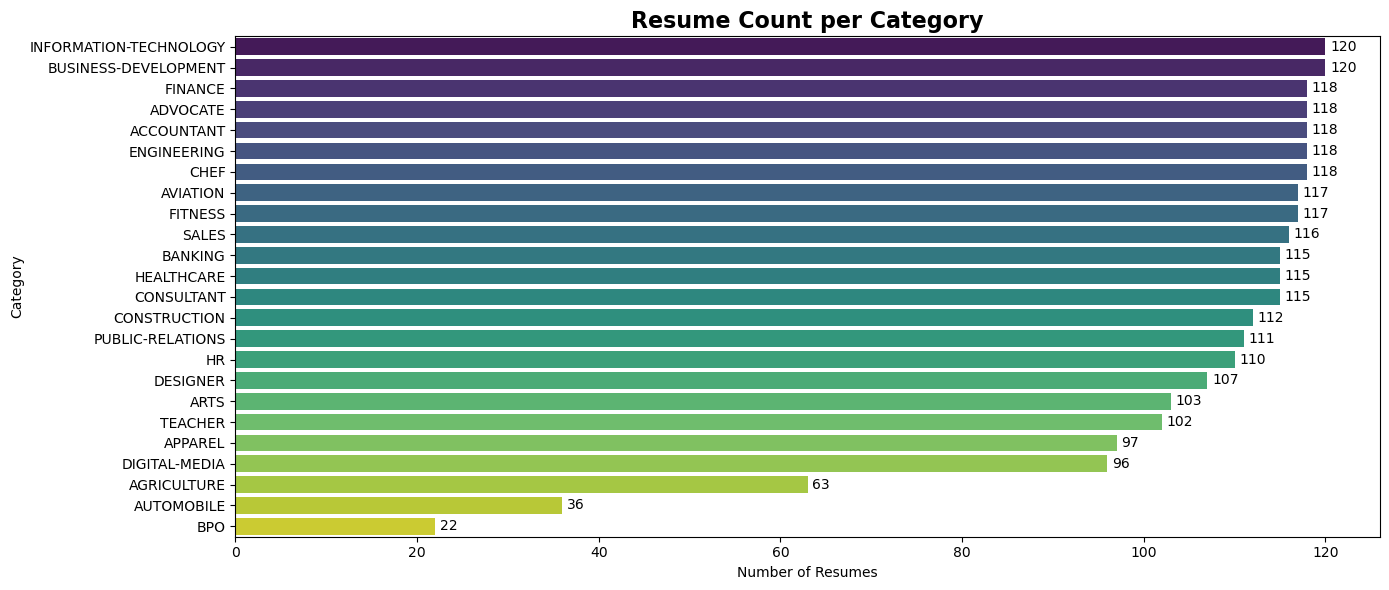

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [24]:
# Category distribution
plt.figure(figsize=(14, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Resume Count per Category', fontsize=16, fontweight='bold')
plt.xlabel('Number of Resumes')
plt.ylabel('Category')
for i, v in enumerate(category_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()
print(category_counts)

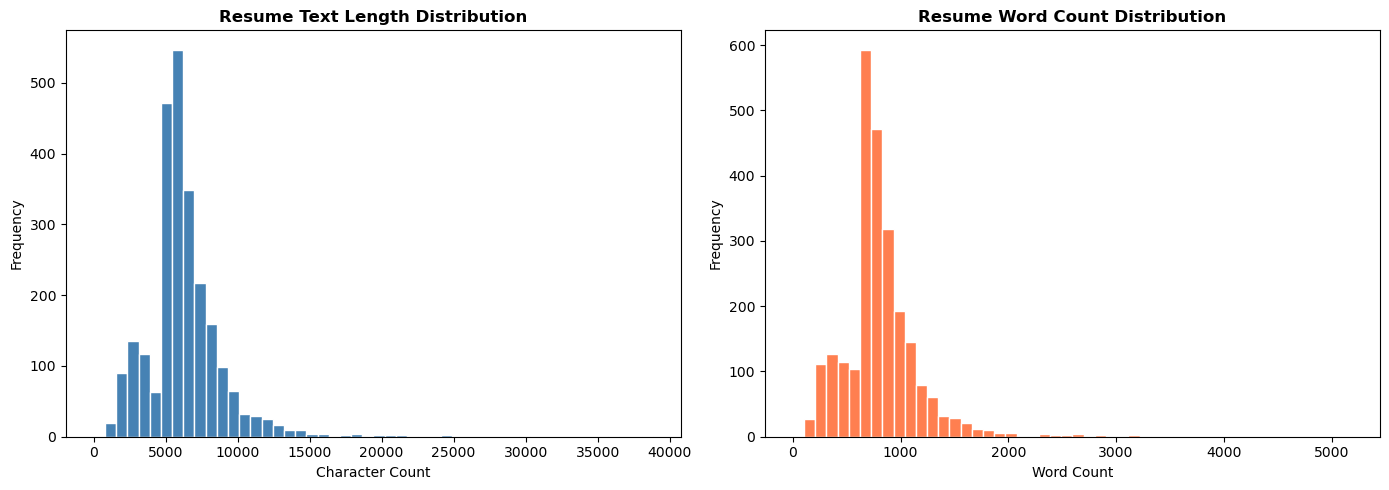

Avg text length : 6295 chars
Avg word count  : 811 words


In [25]:
# Resume text length distribution
df['text_length'] = df['resume_text'].apply(len)
df['word_count'] = df['resume_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Resume Text Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Resume Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150)
plt.show()

print(f'Avg text length : {df["text_length"].mean():.0f} chars')
print(f'Avg word count  : {df["word_count"].mean():.0f} words')

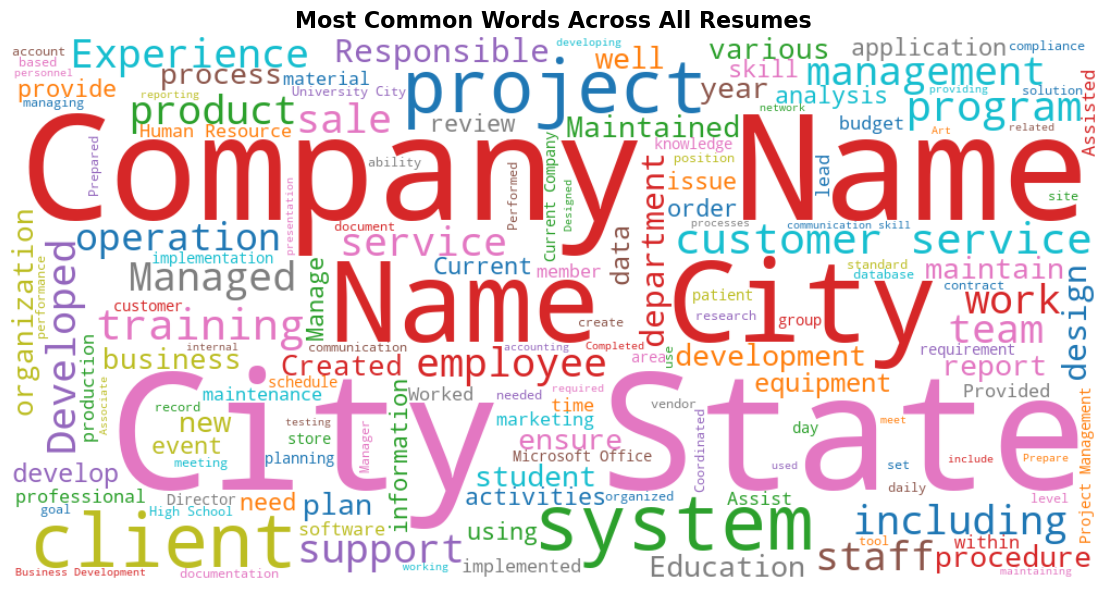

In [26]:
# WordCloud for all resumes
all_text = ' '.join(df['resume_text'].astype(str).tolist())
wc = WordCloud(width=1000, height=500, background_color='white',
               max_words=150, colormap='tab10').generate(all_text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words Across All Resumes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_all.png', dpi=150)
plt.show()

---
## Step 4 — Text Preprocessing & Cleaning

In [27]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    """
    Full text cleaning pipeline for resume text:
    1. Remove URLs
    2. Remove HTML tags
    3. Remove special characters & punctuation
    4. Lowercase
    5. Remove extra whitespace
    6. Remove stopwords
    7. Lemmatize
    """
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove special characters, keep only letters/spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning resumes...')
df['clean_text'] = df['resume_text'].apply(clean_resume)
print('Done ✅')

# Preview
print('\n--- Original (first 300 chars) ---')
print(df['resume_text'].iloc[0][:300])
print('\n--- Cleaned (first 300 chars) ---')
print(df['clean_text'].iloc[0][:300])

Cleaning resumes...
Done ✅

--- Original (first 300 chars) ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

--- Cleaned (first 300 chars) ---
administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction te


---
## Step 5 — Label Encoding

In [28]:
# Encode category labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

print('Category → Label Mapping:')
for i, cat in enumerate(le.classes_):
    print(f'  {cat:<25} → {i}')

num_classes = len(le.classes_)
print(f'\nTotal classes: {num_classes}')

# Save label encoder for later use in app
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Label encoder saved ✅')

Category → Label Mapping:
  ACCOUNTANT                → 0
  ADVOCATE                  → 1
  AGRICULTURE               → 2
  APPAREL                   → 3
  ARTS                      → 4
  AUTOMOBILE                → 5
  AVIATION                  → 6
  BANKING                   → 7
  BPO                       → 8
  BUSINESS-DEVELOPMENT      → 9
  CHEF                      → 10
  CONSTRUCTION              → 11
  CONSULTANT                → 12
  DESIGNER                  → 13
  DIGITAL-MEDIA             → 14
  ENGINEERING               → 15
  FINANCE                   → 16
  FITNESS                   → 17
  HEALTHCARE                → 18
  HR                        → 19
  INFORMATION-TECHNOLOGY    → 20
  PUBLIC-RELATIONS          → 21
  SALES                     → 22
  TEACHER                   → 23

Total classes: 24
Label encoder saved ✅


---
## Step 6 — TF-IDF Vectorization

In [29]:
# Train-test split
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size  : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)')

Train size : 1987 (80.0%)
Test size  : 497  (20.0%)


In [30]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,      # Top 15k features
    ngram_range=(1, 3),      # Unigrams + bigrams
    sublinear_tf=True,       # Log scaling for TF
    min_df=2,                # Ignore very rare words
    max_df=0.95,             # Ignore very common words
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

# Save vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('TF-IDF vectorizer saved ✅')

TF-IDF matrix shape (train): (1987, 10000)
TF-IDF matrix shape (test) : (497, 10000)
TF-IDF vectorizer saved ✅


---
## Step 7 — Train Multiple ML Models (Scikit-learn)

In [31]:
# Define models to compare
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, C=5, random_state=42, class_weight='balanced'),
    'Linear SVM'           : LinearSVC(C=2.0, class_weight='balanced', max_iter=3000),
    'Naive Bayes'          : MultinomialNB(alpha=0.1),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1_score': f1, 'model': model, 'y_pred': y_pred}
    print(f'  Accuracy : {acc:.4f} | F1 Score: {f1:.4f}')

print('\nAll models trained ✅')

Training Logistic Regression...
  Accuracy : 0.6861 | F1 Score: 0.6778
Training Linear SVM...
  Accuracy : 0.7384 | F1 Score: 0.7323
Training Naive Bayes...
  Accuracy : 0.5775 | F1 Score: 0.5523
Training Random Forest...
  Accuracy : 0.7505 | F1 Score: 0.7311

All models trained ✅


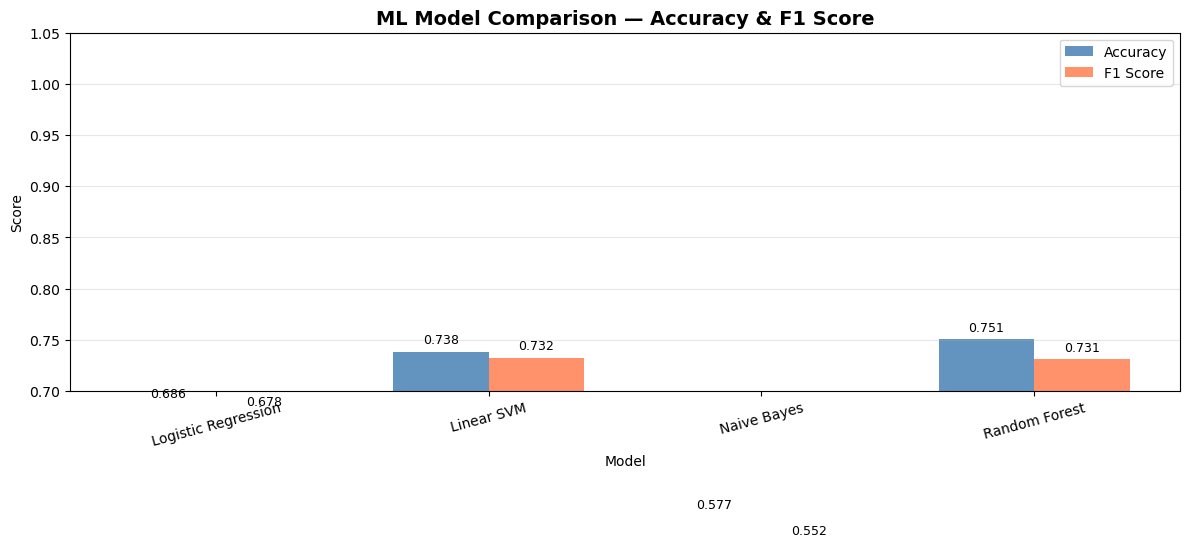

In [32]:
# Compare model performance visually
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['f1_score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Score',  color='coral',     alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('ML Model Comparison — Accuracy & F1 Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [33]:
# Detailed report for best ML model (likely SVM or LR)
best_ml_name = max(results, key=lambda k: results[k]['f1_score'])
best_ml_pred = results[best_ml_name]['y_pred']
print(f'Best ML Model: {best_ml_name}')
print()
print(classification_report(y_test, best_ml_pred, target_names=le.classes_))

Best ML Model: Linear SVM

                        precision    recall  f1-score   support

            ACCOUNTANT       0.76      0.92      0.83        24
              ADVOCATE       0.68      0.71      0.69        24
           AGRICULTURE       0.80      0.62      0.70        13
               APPAREL       0.64      0.37      0.47        19
                  ARTS       0.73      0.52      0.61        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.86      0.79      0.83        24
               BANKING       0.79      0.83      0.81        23
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.70      0.88      0.78        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.75      0.82      0.78        22
            CONSULTANT       0.73      0.48      0.58        23
              DESIGNER       0.90      0.86      0.88        21
         DIG

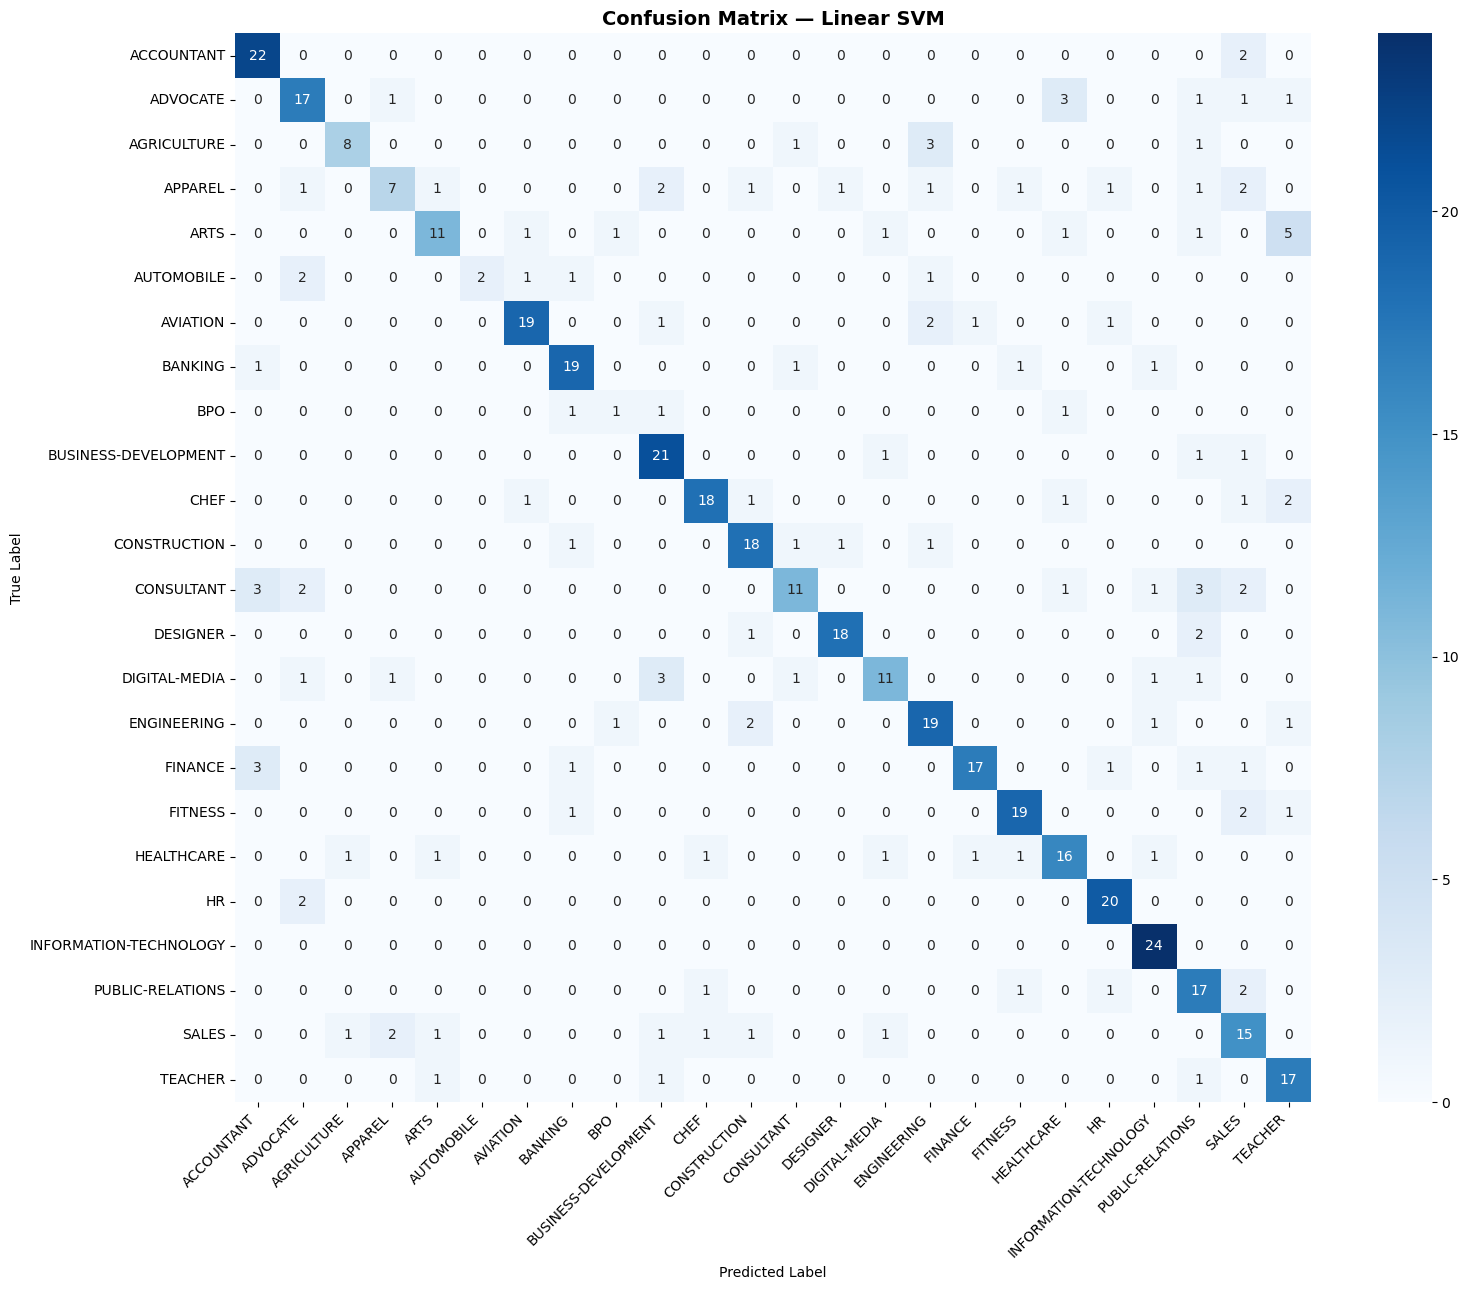

In [34]:
# Confusion matrix for best ML model
cm = confusion_matrix(y_test, best_ml_pred)
plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_ml_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_ml.png', dpi=150)
plt.show()

---
## Step 8 — Final Model Comparison

In [35]:
# Summary table of all models
summary = []
for name, res in results.items():
    summary.append({
        'Model'   : name,
        'Accuracy': round(res['accuracy'], 4),
        'F1 Score': round(res['f1_score'], 4),
        'Type'    : 'ML'
    })

summary_df = pd.DataFrame(summary).sort_values('F1 Score', ascending=False)
print('=== Final Model Comparison ===')
print(summary_df.to_string(index=False))

best_overall = summary_df.iloc[0]['Model']
print(f'\n🏆 Best Model: {best_overall}')

=== Final Model Comparison ===
              Model  Accuracy  F1 Score Type
         Linear SVM    0.7384    0.7323   ML
      Random Forest    0.7505    0.7311   ML
Logistic Regression    0.6861    0.6778   ML
        Naive Bayes    0.5775    0.5523   ML

🏆 Best Model: Linear SVM


---
## Step 9 — Save Models

In [36]:
# Save best ML model
best_ml_model = results[best_ml_name]['model']
with open('model.pkl', 'wb') as f:
    pickle.dump(best_ml_model, f)
print(f'Best ML model saved → best_ml_model.pkl  ({best_ml_name}) ✅')

print('\n=== All saved files ===')
print('  model.pkl       — Best Scikit-learn model')
print('  tfidf_vectorizer.pkl    — TF-IDF vectorizer')
print('  label_encoder.pkl       — Label encoder')

Best ML model saved → best_ml_model.pkl  (Linear SVM) ✅

=== All saved files ===
  model.pkl       — Best Scikit-learn model
  tfidf_vectorizer.pkl    — TF-IDF vectorizer
  label_encoder.pkl       — Label encoder


---
## Step 10 — Prediction Function (Ready for App Integration)

In [37]:
def predict_resume_category(resume_text, use_keras=False):
    """
    Predict the job category for a given resume text.
    
    Args:
        resume_text (str): Raw resume text
        use_keras (bool): Use Keras model (True) or best ML model (False)
    
    Returns:
        dict: predicted category, confidence scores for all categories
    """
    # Clean the text
    cleaned = clean_resume(resume_text)

    # Vectorize
    vec = tfidf.transform([cleaned])

    if use_keras:
        dense = vec.toarray().astype(np.float32)
        probs = keras_model.predict(dense, verbose=0)[0]
        pred_label = np.argmax(probs)
        confidence = probs[pred_label]
        all_probs = dict(zip(le.classes_, probs))
    else:
        pred_label = best_ml_model.predict(vec)[0]
        if hasattr(best_ml_model, 'predict_proba'):
            probs = best_ml_model.predict_proba(vec)[0]
            confidence = probs[pred_label]
            all_probs = dict(zip(le.classes_, probs))
        else:
            confidence = None
            all_probs = None

    predicted_category = le.inverse_transform([pred_label])[0]

    return {
        'predicted_category': predicted_category,
        'confidence': confidence,
        'all_probabilities': all_probs
    }


# ---- Quick Test ----
sample_resume = """
Python developer with 5 years of experience in machine learning and data science.
Skilled in TensorFlow, Keras, scikit-learn, pandas, NumPy.
Worked on NLP models, computer vision, and deep learning projects.
Experience with REST APIs, Docker, AWS, and agile development.
"""

result_ml    = predict_resume_category(sample_resume, use_keras=False)

print('=== Prediction Test ===')
print(f'ML Model    → {result_ml["predicted_category"]}   (confidence: {result_ml["confidence"]})')


=== Prediction Test ===
ML Model    → ENGINEERING   (confidence: None)


---
## ✅ Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Import Libraries | ✅ |
| 2 | Load Dataset (2484 resumes, 24 categories) | ✅ |
| 3 | EDA — Category Distribution, Word Count, WordCloud | ✅ |
| 4 | Text Cleaning — URL/HTML removal, stopwords, lemmatization | ✅ |
| 5 | Label Encoding | ✅ |
| 6 | TF-IDF Vectorization (15k features, bigrams) | ✅ |
| 7 | Train 4 ML Models + Evaluation | ✅ |
| 8 | Train Keras Neural Network (512→256→128→24) | ✅ |
| 9 | Final Model Comparison | ✅ |
| 10 | Save All Models + Vectorizer | ✅ |
| 11 | Prediction Function (ready for Streamlit app) | ✅ |

### Next Step: Build the Streamlit App 🚀
Use the saved files:
- `model.pkl`
- `tfidf_vectorizer.pkl`
- `label_encoder.pkl`